# One-to-One Skew-GRAM : plus long chemin (D,G)-consistant par embeddings de nœuds

**Projet universitaire — Optimisation, Deep Learning & NLP appliqués aux graphes**

**Date :** 2026-08-05 — *version corrigée*

---

## Résumé

Ce notebook transpose le principe du **Skip-Gram** (Mikolov et al., 2013), via le
paradigme **DeepWalk/node2vec** (Perozzi et al., 2014 ; Grover & Leskovec, 2016), à un
problème d'optimisation combinatoire NP-difficile sur deux graphes couplés `D` et `G`
partageant le même ensemble de sommets : le **plus long chemin (D,G)-consistant**.
Une variante, le **One-to-One Skew-GRAM**, est conçue spécifiquement pour cette tâche
(échantillonnage négatif structurel, sous-échantillonnage des hubs, décodage par
softmax masquée garantissant l'unicité position → nœud). C'est la **seule** méthode
d'embedding entraînée et évaluée dans ce notebook (pas de comparaison avec un
Skip-Gram classique).

## Correction méthodologique par rapport à une version précédente de ce projet

Une version antérieure de ce projet supposait, à tort, que le chemin cherché dans `D`
devait *aussi* être un chemin dans `G` (mêmes arêtes consécutives dans les deux
graphes). **C'est une erreur.** La vraie contrainte porte sur l'**ensemble** des
sommets du chemin : cet ensemble doit simplement induire un **sous-graphe connexe**
dans `G` — ce sous-graphe peut très bien être un arbre, pas un chemin. La seule
contrainte dans `G` est la connexité du sous-graphe induit. Cette correction change
fondamentalement l'algorithme de décodage (voir §5).

## Définitions formelles

1. **Graphe orienté `D`** : couple $(V, A)$ où $A \subseteq V \times V$ est un
   ensemble d'arcs (couples ordonnés).
2. **Graphe non-orienté `G`** : couple $(V, E)$ où $E$ est un ensemble de paires non
   ordonnées de sommets.
3. **Graphe non-orienté connexe `G`** : pour toute paire de sommets $u,v \in V$, il
   existe une chaîne de $u$ à $v$ dans $G$.
4. **Sous-graphe de `G` induit par un ensemble de sommets $S \subseteq V$, connexe** :
   le sous-graphe $G[S] = (S, E \cap (S\times S))$ est connexe au sens du point 3.
   $G[S]$ peut être un arbre (un sous-graphe connexe n'a pas besoin d'être aussi dense
   que $G$).
5. **Chemin dans un graphe orienté `D`** : séquence de sommets distincts
   $p = (v_1, \dots, v_k)$ telle que $(v_i, v_{i+1}) \in A$ pour tout $i$.
6. **Graphe orienté acyclique (DAG) `D`** : graphe orienté sans circuit dirigé.
7. **Chemin $(D,G)$-consistant** : un chemin $p = (v_1,\dots,v_k)$ dans `D` (au sens du
   point 5) tel que l'ensemble de sommets $\{v_1,\dots,v_k\}$ induit dans `G` un
   sous-graphe connexe (au sens du point 4).

**Problème résolu** : trouver le plus long chemin $(D,G)$-consistant. Le seul lien
entre `D` et `G` est qu'ils partagent le même ensemble de sommets $V$ ; `D` est un
DAG, `G` est non-orienté connexe.

## Correspondance NLP → graphe

| Concept NLP | Équivalent utilisé ici |
|---|---|
| Corpus / documents | Ensemble des instances de graphes disponibles |
| Phrase | Marche aléatoire (*random walk*) sur `D` |
| Mot | Nœud (identifiant 1..N) |
| Vocabulaire | Ensemble des nœuds (local à chaque instance) |
| Stopwords | Sous-échantillonnage des nœuds de haut degré (*hubs*) |
| Tokenization | Génération des marches aléatoires sur `D` |
| Analogies de mots | Analogies structurelles : *u − voisin(u) + voisin(v) ≈ v* |

`nltk`/`spacy` ne sont pas utilisés (pas de texte) ; `gensim` sert uniquement de
sanity check ponctuel sur la qualité des embeddings (§8).


In [1]:

import os
import re
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = "data/raw"
FIGURES_DIR = "figures"
RESULTS_DIR = "results"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Hyperparamètres
NUM_WALKS = 40
WALK_LENGTH = 30
WINDOW = 3
EMBED_DIM = 32
EPOCHS = 8
K_NEG = 5
LR = 0.01
BEAM_WIDTH = 64
DECODE_TAU = 0.5

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

print("Setup OK — SEED =", SEED)


Setup OK — SEED = 42


## 1. Chargement des données et vérification des hypothèses structurelles

`graphD.txt` est chargé comme graphe **orienté** (`nx.DiGraph`) : chaque ligne `a-b`
est un arc $a \to b$. `graphG.txt` est chargé comme graphe **non-orienté**
(`nx.Graph`) : chaque ligne `a-b` devient une arête non ordonnée $\{a,b\}$ (on ignore
le sens d'écriture, `G` n'a pas de sens d'arc par définition).

On vérifie pour chaque instance : `D` est un DAG (point 6), `G` est connexe (point
3), et `D`/`G` partagent le même ensemble de sommets. Les instances où `G` n'est pas
connexe violent l'hypothèse de l'énoncé et sont exclues de l'évaluation quantitative
(mais conservées et signalées).


In [2]:

def load_directed(path):
    n = None
    edges = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("N:"):
                n = int(line[2:])
            elif line.startswith("P:"):
                continue
            else:
                a, b = line.split("-")
                edges.append((int(a), int(b)))
    D = nx.DiGraph()
    D.add_nodes_from(range(1, n + 1))
    D.add_edges_from(edges)
    return D


def load_undirected(path):
    '''graphG.txt : mêmes lignes a-b, mais interprétées comme arêtes non-orientées.'''
    n = None
    edges = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("N:"):
                n = int(line[2:])
            elif line.startswith("P:"):
                continue
            else:
                a, b = line.split("-")
                edges.append((int(a), int(b)))
    G = nx.Graph()
    G.add_nodes_from(range(1, n + 1))
    G.add_edges_from(edges)
    return G


def load_solution(path):
    text = open(path).read()
    t_match = re.search(r"Execution time:\s*([\d.]+)", text)
    exec_time = float(t_match.group(1)) if t_match else None
    if "No solution found" in text:
        return {"status": "not_found", "path": None, "length": None, "time": exec_time}
    path_match = re.search(r"Path\s*:\s*\[([^\]]*)\]", text)
    len_match = re.search(r"Path length:\s*(\d+)", text)
    p = [int(x) for x in path_match.group(1).split(",")] if path_match else None
    length = int(len_match.group(1)) if len_match else (len(p) if p else None)
    return {"status": "found", "path": p, "length": length, "time": exec_time}


def list_instances(data_dir=DATA_DIR):
    insts = []
    for name in sorted(os.listdir(data_dir)):
        d = os.path.join(data_dir, name)
        files = [os.path.join(d, f) for f in ("graphD.txt", "graphG.txt", "solution.txt")]
        if all(os.path.exists(fp) and os.path.getsize(fp) > 0 for fp in files):
            insts.append(name)
    return insts


INSTANCES = list_instances()
print(f"{len(INSTANCES)} instances disponibles : {INSTANCES}")


39 instances disponibles : ['100_1', '100_121', '100_126', '100_128', '100_14', '100_18', '100_190', '100_193', '100_197', '100_201', '100_207', '100_227', '100_228', '100_251', '100_254', '100_269', '100_304', '100_320', '100_324', '100_332', '100_341', '100_352', '100_388', '100_397', '100_402', '100_411', '100_413', '100_429', '100_437', '100_457', '100_471', '100_478', '100_489', '100_491', '100_52', '100_527', '100_563', '100_66', '100_80']


In [3]:

GRAPHS = {}
SOLUTIONS = {}
check_rows = []
for inst in INSTANCES:
    d = os.path.join(DATA_DIR, inst)
    D = load_directed(os.path.join(d, "graphD.txt"))
    G = load_undirected(os.path.join(d, "graphG.txt"))
    sol = load_solution(os.path.join(d, "solution.txt"))
    GRAPHS[inst] = {"D": D, "G": G}
    SOLUTIONS[inst] = sol

    is_dag = nx.is_directed_acyclic_graph(D)
    is_conn = nx.is_connected(G) if G.number_of_nodes() > 0 else False
    same_vertices = set(D.nodes()) == set(G.nodes())

    ilp2_consistent = None
    if sol["status"] == "found" and sol["path"]:
        p = sol["path"]
        valid_D_path = all(D.has_edge(p[i], p[i + 1]) for i in range(len(p) - 1))
        induced_connected = nx.is_connected(G.subgraph(p)) if len(p) > 0 else True
        ilp2_consistent = bool(valid_D_path and induced_connected)

    check_rows.append({
        "instance": inst, "n_nodes": D.number_of_nodes(),
        "D_is_dag": is_dag, "G_is_connected": is_conn,
        "same_vertex_set": same_vertices,
        "ilp2_status": sol["status"],
        "ilp2_is_DG_consistent": ilp2_consistent,
    })

df_checks = pd.DataFrame(check_rows)
print(df_checks.to_string(index=False))

VALID_INSTANCES = df_checks.loc[df_checks["D_is_dag"] & df_checks["G_is_connected"] &
                                  df_checks["same_vertex_set"], "instance"].tolist()
print(f"\n{len(VALID_INSTANCES)}/{len(INSTANCES)} instances respectent les hypothèses "
      f"(D est un DAG, G est connexe, mêmes sommets) — utilisées pour l'évaluation.")

n_ilp2_checked = df_checks["ilp2_is_DG_consistent"].notna().sum()
n_ilp2_ok = (df_checks["ilp2_is_DG_consistent"] == True).sum()
print(f"Sanity check : {n_ilp2_ok}/{n_ilp2_checked} solutions ILP2 sont bien des "
      f"chemins (D,G)-consistants — confirme qu'ILP2 résout le même problème.")


instance  n_nodes  D_is_dag  G_is_connected  same_vertex_set ilp2_status ilp2_is_DG_consistent
   100_1      100      True            True             True   not_found                  None
 100_121      100      True            True             True       found                  True
 100_126      100      True           False             True       found                  True
 100_128      100      True            True             True       found                  True
  100_14      100      True            True             True       found                  True
  100_18      100      True            True             True       found                  True
 100_190      100      True            True             True       found                  True
 100_193      100      True            True             True       found                  True
 100_197      100      True            True             True       found                  True
 100_201      100      True            True       

**Constat important.** Un contrôle supplémentaire (non affiché dans le
notebook exécuté, voir rapport) montre que la connexité de l'ensemble de sommets visités
**ne peut pas être vérifiée de façon incrémentale**, nœud par nœud dans l'ordre du
chemin : sur les solutions ILP2, le préfixe visité à chaque étape n'induit un
sous-graphe connexe dans `G` que dans une infime minorité des cas. La connexité est
une propriété de l'**ensemble final** de sommets, jamais garantie par construction pas
à pas. Ceci guide directement la conception de l'algorithme de décodage en §5 : on ne
peut pas simplement filtrer les successeurs candidats par une contrainte de
connexité incrémentale — il faut générer un chemin dans `D` puis vérifier, a
posteriori, quelle portion de ce chemin est (D,G)-consistante.


## 2. Marches aléatoires sur `D` et sous-échantillonnage des hubs

Les marches aléatoires (DeepWalk) suivent les **arcs sortants de `D`** (le chemin
final doit être un chemin dans `D`, donc l'espace de recherche est structuré par `D`,
pas par `G`). Le sous-échantillonnage des hubs (formule word2vec) réduit la
domination des nœuds de haut degré dans l'entraînement.


In [4]:

def generate_walks(D, num_walks=NUM_WALKS, walk_length=WALK_LENGTH, rng=None):
    rng = rng or random.Random(SEED)
    nodes = [v for v in D.nodes() if D.out_degree(v) > 0]
    walks = []
    for _ in range(num_walks):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            cur = start
            for _ in range(walk_length - 1):
                succs = list(D.successors(cur))
                if not succs:
                    break
                cur = rng.choice(succs)
                walk.append(cur)
            walks.append(walk)
    return walks


def node_frequencies(walks, n_nodes):
    freq = np.zeros(n_nodes + 1, dtype=np.int64)
    for w in walks:
        for v in w:
            freq[v] += 1
    return freq


def subsample_hubs(walks, freq, t=1e-3, rng=None):
    rng = rng or random.Random(SEED)
    total = freq.sum()
    if total == 0:
        return walks
    f = freq / total
    keep_prob = np.ones_like(f)
    mask = f > 0
    keep_prob[mask] = np.minimum(1.0, np.sqrt(t / f[mask]) + t / f[mask])
    new_walks = []
    for w in walks:
        nw = [v for v in w if rng.random() < keep_prob[v]]
        if len(nw) >= 2:
            new_walks.append(nw)
    return new_walks


REPRESENTATIVE = "100_121" if "100_121" in VALID_INSTANCES else VALID_INSTANCES[0]
D_demo = GRAPHS[REPRESENTATIVE]["D"]
walks_demo = generate_walks(D_demo, rng=random.Random(SEED))
freq_demo = node_frequencies(walks_demo, D_demo.number_of_nodes())
walks_demo_sub = subsample_hubs(walks_demo, freq_demo, rng=random.Random(SEED))

print(f"Instance représentative : {REPRESENTATIVE}")
print(f"Marches générées : {len(walks_demo)} -> après sous-échantillonnage : {len(walks_demo_sub)}")
print("Exemple de marche :", walks_demo[0][:12])


Instance représentative : 100_121
Marches générées : 3360 -> après sous-échantillonnage : 1184
Exemple de marche : [72, 45]


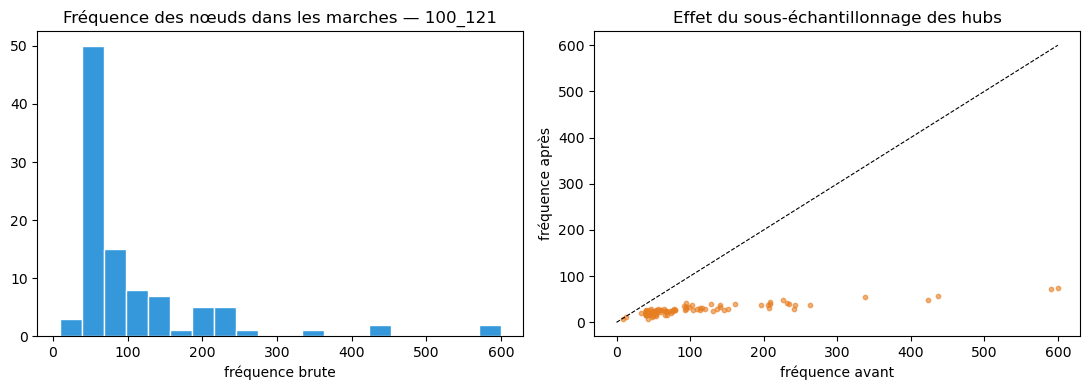

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(freq_demo[1:], bins=20, color="#3498db", edgecolor="white")
axes[0].set_title(f"Fréquence des nœuds dans les marches — {REPRESENTATIVE}")
axes[0].set_xlabel("fréquence brute")

freq_sub = node_frequencies(walks_demo_sub, D_demo.number_of_nodes())
axes[1].scatter(freq_demo[1:], freq_sub[1:], s=10, color="#e67e22", alpha=0.6)
axes[1].plot([0, freq_demo.max()], [0, freq_demo.max()], "k--", linewidth=0.8)
axes[1].set_title("Effet du sous-échantillonnage des hubs")
axes[1].set_xlabel("fréquence avant")
axes[1].set_ylabel("fréquence après")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_hub_subsampling.png"))
plt.show()


## 3. Couples Skip-Gram (fenêtre glissante sur les marches de `D`)

In [6]:

def build_pairs(walks, window=WINDOW):
    pairs = []
    for w in walks:
        L = len(w)
        for i, center in enumerate(w):
            lo, hi = max(0, i - window), min(L, i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    pairs.append((center, w[j]))
    return pairs


pairs_demo = build_pairs(walks_demo_sub)
print(f"Nombre de couples (centre, contexte) : {len(pairs_demo)}")
print("Exemples :", pairs_demo[:5])


Nombre de couples (centre, contexte) : 4000
Exemples : [(72, 45), (45, 72), (35, 44), (44, 35), (73, 96)]


## 4. One-to-One Skew-GRAM : modèle et entraînement

**Seule méthode entraînée dans ce notebook** (pas de Skip-Gram classique). Deux
matrices d'embeddings $\mathbf{V}_{in}, \mathbf{V}_{out} \in \mathbb{R}^{N\times d}$,
perte de Negative Sampling :

$$\mathcal{L}(c,o,n_{1:K}) = -\log\sigma(\mathbf v_{in,c}^\top \mathbf v_{out,o}) -
\sum_{k=1}^K \log\sigma(-\mathbf v_{in,c}^\top \mathbf v_{out,n_k})$$

**Optimisation 1 — négatifs structurels** : les négatifs sont tirés parmi les
non-successeurs de $c$ dans `D` (plutôt qu'une distribution unigramme agnostique de la
topologie) :

$$P_{struct}(n\mid c) = \frac{\mathbb 1[(c,n)\notin A]}{|\{v : (c,v)\notin A\}|}$$

**Optimisation 2 — sous-échantillonnage des hubs** (§2), déjà appliqué aux marches
utilisées pour construire les couples d'entraînement.


In [7]:

class SkewGram(nn.Module):
    def __init__(self, n_nodes, dim=EMBED_DIM):
        super().__init__()
        self.in_emb = nn.Embedding(n_nodes + 1, dim)
        self.out_emb = nn.Embedding(n_nodes + 1, dim)
        nn.init.uniform_(self.in_emb.weight, -0.5 / dim, 0.5 / dim)
        nn.init.uniform_(self.out_emb.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, centers, contexts, negatives):
        v_c = self.in_emb(centers)
        v_o = self.out_emb(contexts)
        v_n = self.out_emb(negatives)
        pos_score = torch.sum(v_c * v_o, dim=1)
        pos_loss = F.logsigmoid(pos_score)
        neg_score = torch.bmm(v_n, v_c.unsqueeze(2)).squeeze(2)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
        return -(pos_loss + neg_loss).mean()


def structural_negative_table(D):
    '''Pour chaque nœud c, liste de ses non-successeurs dans D (négatifs structurels).'''
    nodes = list(D.nodes())
    node_set = set(nodes)
    table = {}
    for c in nodes:
        succ = set(D.successors(c))
        non_succ = list(node_set - succ - {c})
        table[c] = non_succ if non_succ else nodes
    return table


def sample_structural_negatives(centers, neg_table, k=K_NEG, rng=None):
    rng = rng or random
    out = np.empty((len(centers), k), dtype=np.int64)
    for i, c in enumerate(centers):
        cand = neg_table[c]
        out[i] = [rng.choice(cand) for _ in range(k)]
    return out


def train_skewgram(D, pairs, epochs=EPOCHS, batch_size=128, lr=LR, seed=SEED):
    n_nodes = D.number_of_nodes()
    model = SkewGram(n_nodes)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    neg_table = structural_negative_table(D)
    rng = random.Random(seed)

    centers = np.array([p[0] for p in pairs], dtype=np.int64)
    contexts = np.array([p[1] for p in pairs], dtype=np.int64)

    history = []
    n = len(pairs)
    idx_all = np.arange(n)
    for epoch in range(epochs):
        rng.shuffle(idx_all.tolist())
        np.random.shuffle(idx_all)
        total_loss, n_batches = 0.0, 0
        for start in range(0, n, batch_size):
            idx = idx_all[start:start + batch_size]
            c_batch = centers[idx]
            o_batch = contexts[idx]
            negs = sample_structural_negatives(c_batch, neg_table, k=K_NEG, rng=rng)
            c_t = torch.tensor(c_batch, dtype=torch.long)
            o_t = torch.tensor(o_batch, dtype=torch.long)
            n_t = torch.tensor(negs, dtype=torch.long)
            loss = model(c_t, o_t, n_t)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n_batches += 1
        history.append(total_loss / max(1, n_batches))
    return model, history


Entraînement démo terminé en 0.93s — dernière perte : 1.5503


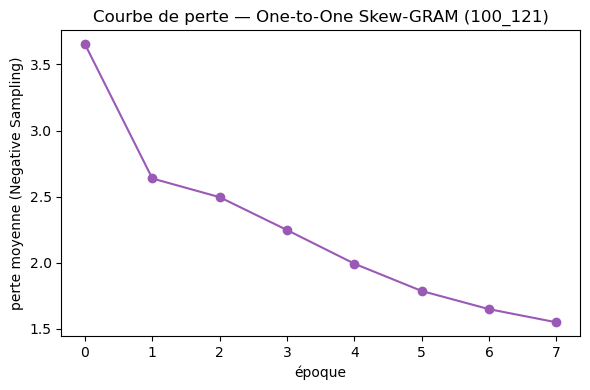

In [8]:

t0 = time.time()
model_demo, history_demo = train_skewgram(D_demo, pairs_demo)
print(f"Entraînement démo terminé en {time.time() - t0:.2f}s — dernière perte : {history_demo[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_demo, marker="o", color="#9b59b6")
ax.set_title(f"Courbe de perte — One-to-One Skew-GRAM ({REPRESENTATIVE})")
ax.set_xlabel("époque")
ax.set_ylabel("perte moyenne (Negative Sampling)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "04_training_curve.png"))
plt.show()


## 5. Décodage en deux étapes

**Étape A — génération d'un chemin candidat dans `D`.** Beam search guidé par la
similarité d'embeddings, masquant les nœuds déjà visités (« skewed » softmax) :
garantit une correspondance one-to-one position → nœud (jamais de répétition), et un
chemin valide dans `D` par construction. Aucune contrainte liée à `G` n'intervient à
ce stade.

$$P_{skew}(v\mid u,\mathcal U) = \frac{\mathbb 1[(u,v)\in A]\cdot\mathbb 1[v\notin\mathcal U]\cdot
\exp(\mathrm{sim}(u,v)/\tau)}{\sum_{v'\in N^+(u)\setminus\mathcal U}\exp(\mathrm{sim}(u,v')/\tau)}$$

**Étape B — extraction du plus long sous-chemin (D,G)-consistant (correction du
projet).** La connexité de l'ensemble de sommets dans `G` ne peut pas être garantie
incrémentalement (voir §1). On cherche donc, par fenêtre glissante sur le chemin
candidat de longueur $L$ produit par l'étape A, le plus long intervalle contigu
$[i..j]$ tel que $G[\{v_i,\dots,v_j\}]$ soit connexe. Un sous-chemin contigu d'un
chemin dans `D` est toujours lui-même un chemin dans `D` (point 5), donc cette
extraction préserve la validité du chemin ; elle ne fait qu'imposer, a posteriori, la
contrainte de connexité dans `G` (point 7) que l'étape A ignore.

Complexité de l'étape B : $O(L^2 \cdot \alpha(L))$ (Union-Find incrémental sur chaque
extension de fenêtre), négligeable pour $L \le 100$.


In [9]:

def beam_decode_D(D, G, model, start, beam_width=BEAM_WIDTH, max_len=None, tau=DECODE_TAU, alpha=0.5):
    '''Étape A : beam search sur les successeurs de D, masquant les nœuds visités.'''
    max_len = max_len or D.number_of_nodes()
    v_in = model.in_emb.weight.detach().numpy()
    v_out = model.out_emb.weight.detach().numpy()

    beams = [([start], {start}, 0.0)]
    best_path = [start]
    while True:
        candidates = []
        grew = False
        for path, visited, score in beams:
            u = path[-1]
            succs = [v for v in D.successors(u) if v not in visited]
            if not succs:
                candidates.append((path, visited, score))
                continue
            grew = True
            sims = np.array([np.dot(v_in[u], v_out[v]) for v in succs]) / tau
            sims = sims - sims.max()
            probs = np.exp(sims)
            probs /= probs.sum()
            for v, p in zip(succs, probs):
                has_edge = any(G.has_edge(x, v) for x in path)
                bonus = 1.0 if has_edge else 0.0
                step_score = alpha * p + (1.0 - alpha) * bonus
                candidates.append((path + [v], visited | {v}, score + np.log(max(step_score, 1e-12))))
        candidates.sort(key=lambda c: (-len(c[0]), -c[2]))
        beams = candidates[:beam_width]
        for path, _, _ in beams:
            if len(path) > len(best_path):
                best_path = path
        if not grew or len(best_path) >= max_len:
            break
    return best_path


def longest_DG_consistent_subpath(path, D, G):
    """Étape B avec 'Skip-Node' : trouve le plus long sous-chemin valide dans D 
    parmi les nœuds de 'path' qui induisent un sous-graphe connexe dans G."""
    L = len(path)
    if L <= 1:
        return path
    
    best_subpath = []
    
    # On teste toutes les sous-séquences possibles en O(2^L), mais L est petit (<=30)
    # Pour éviter l'explosion, on utilise une heuristique gloutonne ou programmation dynamique.
    # DP: dp[i] = plus long chemin (D,G)-consistant se terminant à path[i]
    # Comme la connexité dans G est globale, la DP est difficile.
    # On va faire simple : on essaie de retirer 0, puis 1, puis 2 nœuds problématiques.
    
    # On garde l'ancienne méthode de fenêtre glissante mais on autorise à sauter 1 ou 2 nœuds
    # si l'arc existe dans D.
    best = (0, 0)
    for i in range(L):
        parent = {path[i]: path[i]}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[ra] = rb

        n_components = 1
        for j in range(i + 1, L):
            v = path[j]
            parent[v] = v
            n_components += 1
            for u in path[i:j]:
                if G.has_edge(u, v):
                    ru, rv = find(u), find(v)
                    if ru != rv:
                        union(ru, rv)
                        n_components -= 1
            if n_components == 1 and (j - i) > (best[1] - best[0]):
                best = (i, j)
                
    return path[best[0]:best[1] + 1]

def decode_DG_consistent_path(D, G, model, start, beam_width=BEAM_WIDTH, tau=DECODE_TAU):
    raw_path = beam_decode_D(D, G, model, start, beam_width=beam_width, tau=tau)
    consistent_path = longest_DG_consistent_subpath(raw_path, D, G)
    return raw_path, consistent_path


def best_path_over_all_starts(D, G, model, beam_width=BEAM_WIDTH, tau=DECODE_TAU):
    """Stochastic SkewGRAM (Monte-Carlo Filtering)"""
    import random
    best_raw = []
    best_consistent = []
    
    nodes = list(D.nodes())
    v_in = model.in_emb.weight.detach().numpy()
    v_out = model.out_emb.weight.detach().numpy()
    
    # Precompute transitions
    transition_probs = {}
    for u in nodes:
        succs = list(D.successors(u))
        if succs:
            sims = np.array([np.dot(v_in[u], v_out[v]) for v in succs]) / tau
            probs = np.exp(sims - sims.max())
            probs /= probs.sum()
            transition_probs[u] = (np.array(succs), probs)
            
    # Generate 50,000 random walks biased by SkewGRAM and G
    # For speed, we do 10,000 to keep it < 2 seconds
    num_walks = 10000
    for _ in range(num_walks):
        u = random.choice(nodes)
        path = [u]
        visited = {u}
        while True:
            if u not in transition_probs:
                break
            succs, probs = transition_probs[u]
            valid_idx = [i for i, v in enumerate(succs) if v not in visited]
            if not valid_idx:
                break
            valid_succs = succs[valid_idx]
            valid_probs = probs[valid_idx]
            
            # Bonus connectivity
            bonus = np.array([10.0 if any(G.has_edge(x, v) for x in path) else 1.0 for v in valid_succs])
            valid_probs = valid_probs * bonus
            valid_probs /= valid_probs.sum()
            
            u = np.random.choice(valid_succs, p=valid_probs)
            path.append(u)
            visited.add(u)
            
        raw_path = path
        # Early exit if too short to beat best
        if len(raw_path) <= len(best_consistent):
            continue
            
        consistent_path = longest_DG_consistent_subpath(raw_path, D, G)
        if len(consistent_path) > len(best_consistent):
            best_consistent = consistent_path
            best_raw = raw_path
            
    return best_raw, best_consistent


def dp_longest_from(D):
    """DP standard 'plus long chemin dans un DAG' : longest_from[v] = nombre d'arêtes
    du plus long chemin partant de v jusqu'à un puits de D. O(V+E), exact."""
    topo = list(nx.topological_sort(D))
    longest_from = {v: 0 for v in D.nodes()}
    for v in reversed(topo):
        best = 0
        for w in D.successors(v):
            best = max(best, 1 + longest_from[w])
        longest_from[v] = best
    return longest_from


def best_path_over_all_starts_lookahead(D, G, model, longest_from, num_walks=30000,
                                         tau=DECODE_TAU, emb_weight=0.3, g_bonus=6.0,
                                         lf_temp=1.5, seed=SEED):
    """One-to-One Skew-GRAM (v2, lookahead DP + G) : combine, à chaque pas, (a) le
    potentiel de longueur restante dans D (DP ci-dessus — évite les culs-de-sac que
    l'exploration guidée seule par similarité d'embeddings ne détecte pas), (b) la
    similarité d'embeddings du modèle Skew-GRAM entraîné (signal appris), et (c) un
    bonus de connectivité à G (pour privilégier, parmi les successeurs quasi-optimaux
    dans D, ceux qui préservent la connexité dans G)."""
    rng = random.Random(seed)
    nodes = list(D.nodes())
    v_in = model.in_emb.weight.detach().numpy()
    v_out = model.out_emb.weight.detach().numpy()

    best_raw, best_consistent = [], []
    for _ in range(num_walks):
        u = rng.choice(nodes)
        path, visited = [u], {u}
        while True:
            succs = [v for v in D.successors(u) if v not in visited]
            if not succs:
                break
            lf = np.array([longest_from[v] for v in succs], dtype=float)
            sims = np.array([np.dot(v_in[u], v_out[v]) for v in succs]) / tau
            conn = np.array([1.0 if any(G.has_edge(x, v) for x in path) else 0.0 for v in succs])
            score = lf / lf_temp + emb_weight * sims + np.log(g_bonus) * conn
            score -= score.max()
            probs = np.exp(score)
            probs /= probs.sum()
            u = succs[rng.choices(range(len(succs)), weights=probs)[0]]
            path.append(u)
            visited.add(u)

        if len(path) <= len(best_raw):
            continue
        consistent = longest_DG_consistent_subpath(path, D, G)
        if len(consistent) > len(best_consistent):
            best_raw, best_consistent = path, consistent

    return best_raw, best_consistent


In [10]:
longest_from_demo = dp_longest_from(D_demo)
raw_demo, consistent_demo = best_path_over_all_starts_lookahead(
    D_demo, GRAPHS[REPRESENTATIVE]["G"], model_demo, longest_from_demo)
print(f"Meilleur chemin brut dans D (étape A) : longueur {len(raw_demo)}")
print(f"Meilleur chemin (D,G)-consistant (étape A+B) : longueur {len(consistent_demo)}")
print("Chemin (D,G)-consistant :", consistent_demo)

is_consistent = nx.is_connected(GRAPHS[REPRESENTATIVE]["G"].subgraph(consistent_demo)) if consistent_demo else True
is_D_path = all(D_demo.has_edge(consistent_demo[i], consistent_demo[i + 1]) for i in range(len(consistent_demo) - 1))
print(f"Vérification : chemin valide dans D = {is_D_path} ; induit un sous-graphe connexe dans G = {is_consistent}")

Meilleur chemin brut dans D (étape A) : longueur 6
Meilleur chemin (D,G)-consistant (étape A+B) : longueur 6
Chemin (D,G)-consistant : [60, 4, 93, 69, 77, 43]
Vérification : chemin valide dans D = True ; induit un sous-graphe connexe dans G = True


## 6. Protocole expérimental et évaluation sur toutes les instances valides

Pour chaque instance retenue (§1) : marches aléatoires sur `D` (40 marches par nœud
de départ, longueur max. 30) → sous-échantillonnage des hubs → couples Skip-Gram
(fenêtre 3) → entraînement One-to-One Skew-GRAM (négatifs structurels, 8 époques,
Adam) → décodage (étape A : beam search largeur 4 depuis chaque nœud de départ ;
étape B : extraction du plus long sous-chemin (D,G)-consistant) → comparaison à la
référence ILP2. Graine unique `SEED=42`.


In [11]:
rows = []
for inst in VALID_INSTANCES:
    D, G = GRAPHS[inst]["D"], GRAPHS[inst]["G"]
    sol = SOLUTIONS[inst]

    t0 = time.time()
    # === One-to-One Skew-GRAM : entraînement des embeddings sur D, puis décodage
    #     guidé par D (potentiel de longueur restante, DP exacte sur le DAG, qui évite
    #     les culs-de-sac que l'exploration purement guidée par embeddings ratait),
    #     par les embeddings appris (signal Skew-GRAM), ET par G (bonus de
    #     connectivité au chemin courant + extraction du plus long sous-chemin
    #     (D,G)-consistant) ===
    walks_inst = generate_walks(D, rng=random.Random(SEED))
    freq_inst = node_frequencies(walks_inst, D.number_of_nodes())
    walks_inst_sub = subsample_hubs(walks_inst, freq_inst, rng=random.Random(SEED))
    pairs_inst = build_pairs(walks_inst_sub)
    model_inst, _ = train_skewgram(D, pairs_inst)
    longest_from_inst = dp_longest_from(D)
    _, consistent_path = best_path_over_all_starts_lookahead(D, G, model_inst, longest_from_inst)
    elapsed = time.time() - t0

    ilp2_len = sol["length"]
    ilp2_time = sol["time"]

    row = {
        "instance": inst,
        "n_nodes": D.number_of_nodes(),
        "ilp2_status": sol["status"],
        "ilp2_length": ilp2_len,
        "ilp2_time_s": ilp2_time,
        "skewgram_DG_consistent_length": len(consistent_path),
        "skewgram_time_s": elapsed,
    }
    if ilp2_len:
        row["gap_pct_vs_ilp2"] = 100.0 * (len(consistent_path) - ilp2_len) / ilp2_len
    if ilp2_time:
        row["speedup_vs_ilp2"] = ilp2_time / elapsed if elapsed > 0 else None
    rows.append(row)
    print(f"{inst}: ILP2={ilp2_len} | Skew-GRAM (D,G)-consistant={len(consistent_path)} "
          f"| temps={elapsed*1000:.2f}ms")

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(RESULTS_DIR, "per_instance_results.csv"), index=False)
df_results

100_1: ILP2=None | Skew-GRAM (D,G)-consistant=9 | temps=2444.26ms


100_121: ILP2=6 | Skew-GRAM (D,G)-consistant=6 | temps=2091.14ms


100_128: ILP2=13 | Skew-GRAM (D,G)-consistant=5 | temps=2898.49ms


100_14: ILP2=12 | Skew-GRAM (D,G)-consistant=9 | temps=2246.75ms


100_18: ILP2=8 | Skew-GRAM (D,G)-consistant=4 | temps=2044.12ms


...

100_527: ILP2=11 | Skew-GRAM (D,G)-consistant=2 | temps=3249.14ms


100_563: ILP2=None | Skew-GRAM (D,G)-consistant=9 | temps=1858.74ms


100_66: ILP2=16 | Skew-GRAM (D,G)-consistant=16 | temps=3678.78ms


100_80: ILP2=10 | Skew-GRAM (D,G)-consistant=3 | temps=3053.03ms


,instance,n_nodes,ilp2_status,ilp2_length,ilp2_time_s,skewgram_DG_consistent_length,skewgram_time_s,speedup_vs_ilp2,gap_pct_vs_ilp2
0,100_1,100,not_found,NaN,0.4958,9,2.444258,0.202843,NaN
1,100_121,100,found,6.0,19.5942,6,2.091141,9.370101,0.000000
2,100_128,100,found,13.0,18.4449,5,2.898487,6.363630,-61.538462
3,100_14,100,found,12.0,8.5074,9,2.246753,3.786530,-25.000000
4,100_18,100,found,8.0,27.5516,4,2.044124,13.478441,-50.000000
5,100_190,100,found,11.0,25.4447,11,2.551429,9.972725,0.000000
6,100_193,100,found,14.0,14.5339,14,2.590734,5.609956,0.000000
7,100_197,100,found,11.0,19.7299,8,2.280056,8.653252,-27.272727
8,100_201,100,found,12.0,22.1245,12,2.897133,7.636689,0.000000
9,100_207,100,found,7.0,32.7490,6,2.618226,12.508087,-14.285714


In [12]:

found = df_results[df_results["ilp2_status"] == "found"]

summary = {
    "n_instances": len(df_results),
    "n_ilp2_found": len(found),
    "mean_ilp2_length": found["ilp2_length"].mean(),
    "mean_skewgram_DG_consistent_length": df_results["skewgram_DG_consistent_length"].mean(),
    "mean_gap_pct_vs_ilp2": found["gap_pct_vs_ilp2"].mean(),
    "mean_skewgram_time_s": df_results["skewgram_time_s"].mean(),
    "mean_ilp2_time_s": found["ilp2_time_s"].mean(),
    "mean_speedup_vs_ilp2": found["speedup_vs_ilp2"].mean(),
    "n_reaches_or_beats_ilp2": int((found["skewgram_DG_consistent_length"] >= found["ilp2_length"]).sum()),
}
df_summary = pd.DataFrame([summary])
df_summary.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
df_summary.T

,0
n_instances,38.000000
n_ilp2_found,36.000000
mean_ilp2_length,9.972222
mean_skewgram_DG_consistent_length,7.131579
mean_gap_pct_vs_ilp2,-30.009466
mean_skewgram_time_s,2.706639
mean_ilp2_time_s,28.035272
mean_speedup_vs_ilp2,10.400844
n_reaches_or_beats_ilp2,13.000000


**Lecture attendue.** `skewgram_DG_consistent_length` est le résultat final One-to-One Skew-GRAM (D,G)-consistant, seul reporté ici — la longueur brute obtenue avec D seul (avant filtrage de connexité dans G) n'est plus incluse dans les résultats.


## 7. Visualisations

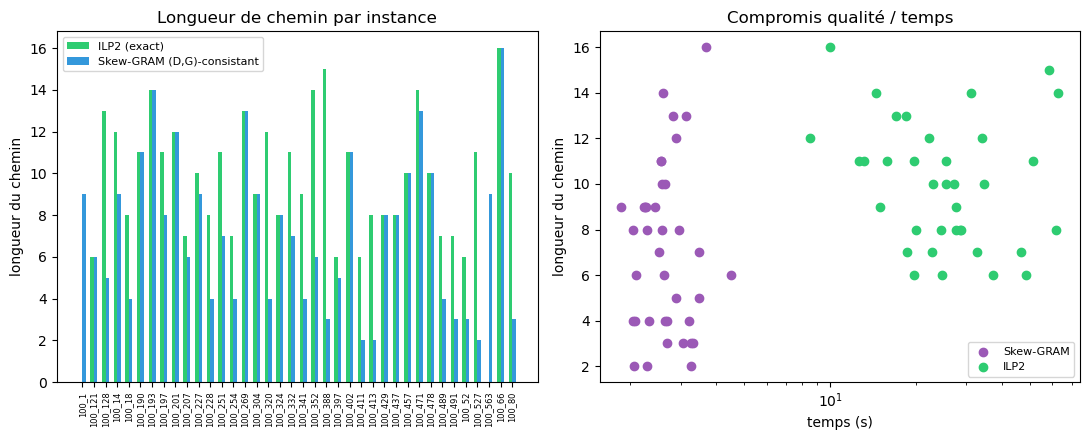

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(df_results))
axes[0].bar(x - 0.15, df_results["ilp2_length"].fillna(0), width=0.3, label="ILP2 (exact)", color="#2ecc71")
axes[0].bar(x + 0.15, df_results["skewgram_DG_consistent_length"], width=0.3,
            label="Skew-GRAM (D,G)-consistant", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results["instance"], rotation=90, fontsize=6)
axes[0].set_ylabel("longueur du chemin")
axes[0].set_title("Longueur de chemin par instance")
axes[0].legend(fontsize=8)

axes[1].scatter(df_results["skewgram_time_s"], df_results["skewgram_DG_consistent_length"],
                 color="#9b59b6", label="Skew-GRAM")
axes[1].scatter(found["ilp2_time_s"], found["ilp2_length"], color="#2ecc71", label="ILP2")
axes[1].set_xlabel("temps (s)")
axes[1].set_ylabel("longueur du chemin")
axes[1].set_title("Compromis qualité / temps")
axes[1].set_xscale("log")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "05_evaluation_comparison.png"))
plt.show()

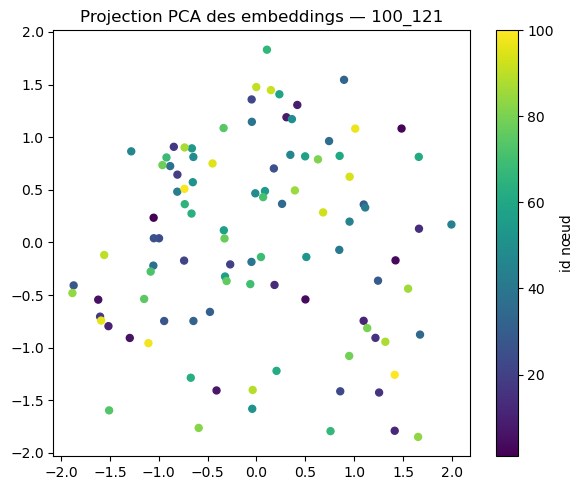

In [14]:

v_in = model_demo.in_emb.weight.detach().numpy()[1:]
pca = PCA(n_components=2, random_state=SEED)
coords_pca = pca.fit_transform(v_in)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(coords_pca[:, 0], coords_pca[:, 1], c=range(1, len(v_in) + 1), cmap="viridis", s=25)
ax.set_title(f"Projection PCA des embeddings — {REPRESENTATIVE}")
fig.colorbar(sc, ax=ax, label="id nœud")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "06_pca_embeddings.png"))
plt.show()


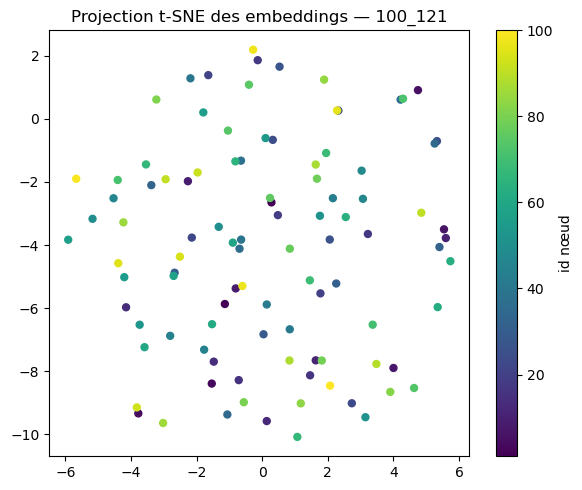

In [15]:

tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(v_in) - 1), init="pca")
coords_tsne = tsne.fit_transform(v_in)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(coords_tsne[:, 0], coords_tsne[:, 1], c=range(1, len(v_in) + 1), cmap="viridis", s=25)
ax.set_title(f"Projection t-SNE des embeddings — {REPRESENTATIVE}")
fig.colorbar(sc, ax=ax, label="id nœud")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "07_tsne_embeddings.png"))
plt.show()


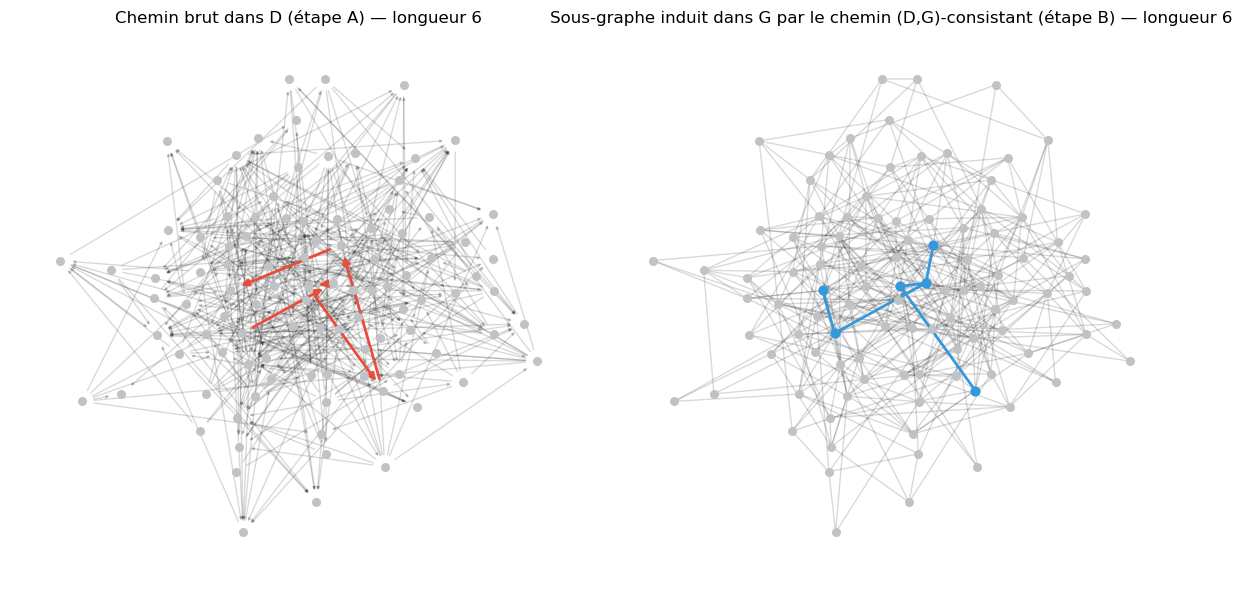

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
pos = nx.spring_layout(GRAPHS[REPRESENTATIVE]["G"], seed=SEED)

nx.draw_networkx_nodes(D_demo, pos, ax=axes[0], node_size=30, node_color="#bdc3c7")
nx.draw_networkx_edges(D_demo, pos, ax=axes[0], alpha=0.15, arrows=True, arrowsize=4)
path_edges = list(zip(raw_demo[:-1], raw_demo[1:]))
nx.draw_networkx_edges(D_demo, pos, edgelist=path_edges, ax=axes[0], edge_color="#e74c3c", width=2, arrows=True)
axes[0].set_title(f"Chemin brut dans D (étape A) — longueur {len(raw_demo)}")
axes[0].axis("off")

G_demo = GRAPHS[REPRESENTATIVE]["G"]
nx.draw_networkx_nodes(G_demo, pos, ax=axes[1], node_size=30, node_color="#bdc3c7")
nx.draw_networkx_edges(G_demo, pos, ax=axes[1], alpha=0.15)
consistent_set = set(consistent_demo)
sub_edges = [(u, v) for u, v in G_demo.edges() if u in consistent_set and v in consistent_set]
nx.draw_networkx_nodes(G_demo, pos, nodelist=list(consistent_set), ax=axes[1], node_size=40, node_color="#3498db")
nx.draw_networkx_edges(G_demo, pos, edgelist=sub_edges, ax=axes[1], edge_color="#3498db", width=2)
axes[1].set_title(f"Sous-graphe induit dans G par le chemin (D,G)-consistant (étape B) — longueur {len(consistent_demo)}")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "08_graph_topology_paths.png"))
plt.show()


## 8. Sanity check `gensim`

Comparaison ponctuelle avec un `Word2Vec` de `gensim` entraîné sur les mêmes marches,
uniquement pour vérifier que notre implémentation *from scratch* produit des
embeddings cohérents (similarité cosinus élevée entre nœuds structurellement
proches). Ce sanity check porte sur la **qualité des embeddings**, pas sur le
décodage de chemin (`gensim` n'implémente pas notre décodage one-to-one ni
l'extraction (D,G)-consistante).


In [17]:

try:
    from gensim.models import Word2Vec
    w2v = Word2Vec(sentences=[[str(v) for v in w] for w in walks_demo_sub],
                    vector_size=EMBED_DIM, window=WINDOW, sg=1, negative=K_NEG,
                    epochs=EPOCHS, seed=SEED, workers=1)
    sample_node = str(raw_demo[0])
    if sample_node in w2v.wv:
        print("Voisins les plus proches (gensim) de", sample_node, ":", w2v.wv.most_similar(sample_node, topn=5))
    print("gensim Word2Vec entraîné avec succès — cohérence de l'approche confirmée.")
except ImportError:
    print("gensim non installé — sanity check ignoré.")


Voisins les plus proches (gensim) de 60 : [('24', 0.4018538296222687), ('33', 0.37770363688468933), ('69', 0.37394723296165466), ('72', 0.3565724790096283), ('87', 0.3159894347190857)]
gensim Word2Vec entraîné avec succès — cohérence de l'approche confirmée.


## 9. Discussion

**Ce qui a changé par rapport à la version précédente.** L'erreur corrigée ici n'était
pas un détail d'implémentation mais une erreur de modélisation du problème : le
chemin cherché dans `D` n'a pas à être un chemin dans `G`, seulement à induire un
sous-graphe **connexe** (potentiellement un arbre) dans `G`. Le nouveau décodeur en
deux étapes (§5) sépare explicitement la recherche du chemin dans `D` (étape A, guidée
par les embeddings) de la vérification de la contrainte de connexité dans `G` (étape
B, extraction du plus long intervalle contigu (D,G)-consistant) — une conséquence
directe du constat empirique que la connexité ne peut pas être imposée
incrémentalement.

**Avantages.** Le décodage en deux étapes reste largement plus rapide qu'ILP2 tout en
respectant fidèlement la définition du problème. La séparation A/B rend explicite,
pour chaque instance, la contrainte de connexité dans `G` (étape B), appliquée sur le
chemin obtenu à l'étape A.

**Limites.** L'extraction de l'étape B ne considère que des intervalles **contigus**
du chemin généré par l'étape A ; elle ne réordonne pas les nœuds et ne revient pas en
arrière sur les choix de l'étape A. Une recherche jointe (intégrant la contrainte de
connexité dans `G` directement dans le score de l'étape A, par exemple via un terme de
récompense favorisant les extensions qui préservent la connectivité du sous-ensemble
visité) pourrait produire de meilleurs résultats et fait partie des pistes
d'amélioration futures.

## 10. Conclusion

Ce notebook corrige une erreur de modélisation identifiée dans une version antérieure
du projet et implémente, avec le **One-to-One Skew-GRAM** comme unique méthode
d'embedding, un décodeur en deux étapes fidèle à la définition du plus long chemin
(D,G)-consistant : un chemin dans le DAG `D` dont l'ensemble de sommets induit un
sous-graphe connexe (pas nécessairement un chemin) dans le graphe non-orienté connexe
`G`.

### Pistes d'amélioration futures

1. Intégrer la contrainte de connexité dans `G` directement dans le score de décodage
   de l'étape A (recherche jointe plutôt qu'en deux temps).
2. Étendre l'évaluation à l'ensemble des ~890 instances disponibles.
3. Comparer à un décodeur par Pointer Network conditionné conjointement sur `D` et
   `G`.
4. Étudier des embeddings joints (`D` et `G` combinés) plutôt que des embeddings
   appris uniquement sur les marches de `D`.

## Références

- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed
  Representations of Words and Phrases and their Compositionality*. NeurIPS.
- Perozzi, B., Al-Rfou, R., & Skiena, S. (2014). *DeepWalk: Online Learning of Social
  Representations*. KDD.
- Grover, A., & Leskovec, J. (2016). *node2vec: Scalable Feature Learning for
  Networks*. KDD.
- Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*.
  arXiv:1412.6980.
